# Adaptive Risk Fusion Comparison


## 1) Mount Google Drive


In [3]:
!git -C /content/AI_Agentic_DL pull


fatal: cannot change to '/content/AI_Agentic_DL': No such file or directory


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import torch

if torch.cuda.is_available():
    print("GPU is enabled")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT enabled")

GPU is enabled
GPU Name: Tesla T4


## 2) Install Dependencies


In [5]:
!pip install -q scikit-learn matplotlib seaborn pandas numpy torch


## 3) Verify Dataset and Project Path


In [6]:
import os
import sys
from pathlib import Path

DATA_PATH = "/content/drive/MyDrive/Deep Learning Project/AI Agentic/data/processed"
REPO_PATH = "/content/AI_Agentic_DL"
BRANCH = "risk-fusion-experiments"

print("Dataset path:", DATA_PATH)
print("Files:", os.listdir(DATA_PATH))

required = ["X_train.npy", "X_test.npy", "y_train.npy", "y_test.npy"]
missing = [f for f in required if not os.path.exists(os.path.join(DATA_PATH, f))]
if missing:
    raise FileNotFoundError(f"Missing required files: {missing}")


if Path(REPO_PATH, ".git").exists():
    !git -C /content/AI_Agentic_DL fetch --all
    !git -C /content/AI_Agentic_DL checkout {BRANCH}
    !git -C /content/AI_Agentic_DL pull
else:
    !git clone -q -b {BRANCH} https://github.com/Lawapaul/AI_Agentic_DL.git /content/AI_Agentic_DL

exp_file = Path(REPO_PATH) / "experiments" / "risk_fusion_comparison.py"
if not exp_file.exists():
    raise FileNotFoundError(f"Missing file: {exp_file}")

if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

print("Repo path used:", REPO_PATH)


Dataset path: /content/drive/MyDrive/Deep Learning Project/AI Agentic/data/processed
Files: ['y_train.npy', 'X_train.npy', 'X_test.npy', 'y_test.npy']
Repo path used: /content/AI_Agentic_DL


## 4) Run Experiment Script Directly


Running on 50k Samples

In [8]:
# Use experiments/risk_fusion_comparison.py directly (with import fallback)
try:
    from experiments.risk_fusion_comparison import evaluate
except ModuleNotFoundError:
    import importlib.util
    module_path = os.path.join(REPO_PATH, 'experiments', 'risk_fusion_comparison.py')
    spec = importlib.util.spec_from_file_location('risk_fusion_comparison', module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    evaluate = module.evaluate

results = evaluate(
    processed_path=DATA_PATH,
    output_dir='experiments/results',
    max_samples=50000 
)
results



,Method,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.96044,0.640167,0.569844,0.598854
1,RandomForest,0.95676,0.635550,0.562142,0.591990
2,Weighted,0.91612,0.634749,0.444140,0.484168
3,Dynamic,0.90512,0.630691,0.414753,0.446904
4,Fuzzy,0.90272,0.625754,0.409274,0.439233
5,Attention,0.12512,0.041715,0.333227,0.074148


## 5) Comparison Charts


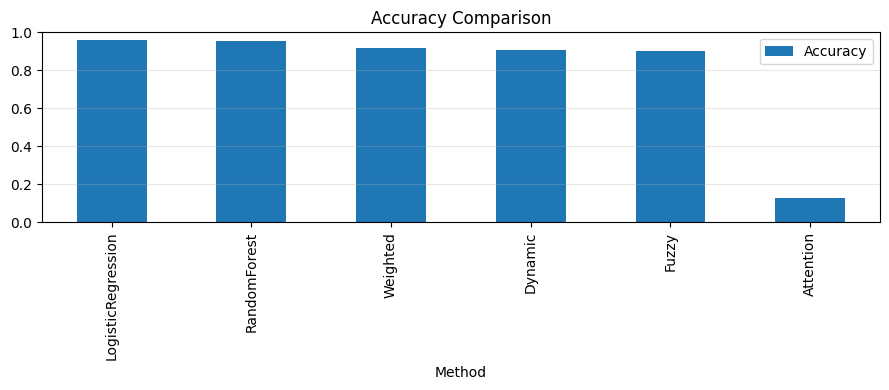

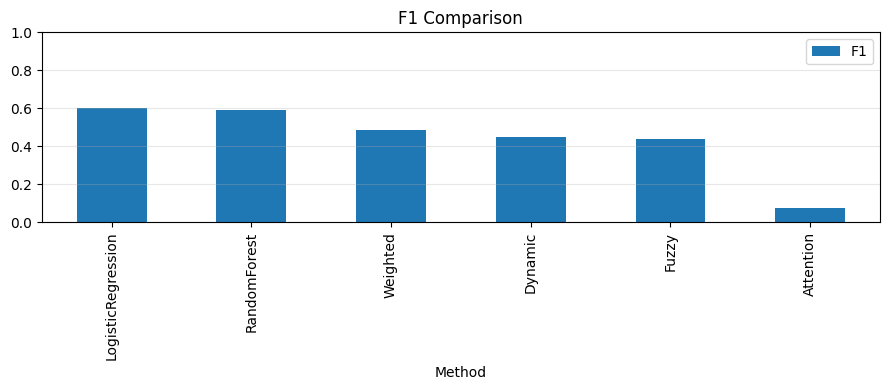

In [9]:
import matplotlib.pyplot as plt

results.plot(x='Method', y='Accuracy', kind='bar', figsize=(9,4), ylim=(0,1), title='Accuracy Comparison')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

results.plot(x='Method', y='F1', kind='bar', figsize=(9,4), ylim=(0,1), title='F1 Comparison')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



## 6) Best Method


In [10]:
best = results.sort_values('F1', ascending=False).iloc[0]
print('Best Fusion Method:', best['Method'])
print(best.to_string())



Best Fusion Method: LogisticRegression
Method       LogisticRegression
Accuracy                0.96044
Precision              0.640167
Recall                 0.569844
F1                     0.598854
